# Lab 2: Differential gene expression in dexamethasone-treated airway smooth muscle cells

**Course:** PUBH 4201 — Applied Computing in Health Data Science
**Dataset:** GEO [GSE52778](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE52778) — Himes et al. 2014, RNA-seq of 4 primary human airway smooth muscle cell lines, each profiled untreated and after dexamethasone (a corticosteroid) treatment. This is the dataset behind Bioconductor's `airway` package and basically every intro DESeq2 tutorial, so there's a well-documented "right answer" to check my own results against.

**Question:** which genes change expression the most between untreated and dexamethasone-treated airway smooth muscle cells, and do the genes that show up match what the original paper found (known glucocorticoid-response genes like `FKBP5`, `TSC22D3`, `KLF15`, `DUSP1`)?

Data are loaded directly from GEO below — no local/pre-cleaned copy.

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)

## 1. Load the data straight from GEO

This is the processed FPKM matrix GEO hosts for this series (Cufflinks output from the original processing pipeline). It's ~6MB unzipped so this takes a few seconds.

In [2]:
url = (
    "https://www.ncbi.nlm.nih.gov/geo/download/"
    "?acc=GSE52778&format=file&file=GSE52778_All_Sample_FPKM_Matrix.txt.gz"
)
# heads up: this file LOOKS tab-separated if you peek at it in a text editor, but it's
# actually just space-separated -- sep="\t" silently reads the whole row as one column
fpkm = pd.read_csv(url, sep=r"\s+", compression="gzip")
print(fpkm.shape)
fpkm.head()

(23273, 41)


,gene_id,tracking_id,class_code,nearest_ref_id,gene_short_name,tss_id,locus,length,coverage,Dex_FPKM,...,Alb_LL11,Alb_LL15,Untreated_LL09,Untreated_LL05,Untreated_LL13,Untreated_LL01,Alb_Dex_LL08,Alb_Dex_LL04,Alb_Dex_LL12,Alb_Dex_LL16
0,1/2-SBSRNA4,1/2-SBSRNA4,-,-,1/2-SBSRNA4,TSS17399,chr4:110351118-110461615,-,-,0.483373,...,0.243635,0.782332,0.418303,0.458863,0.660772,0.530271,0.503827,0.128484,0.138258,0.567435
1,A1BG,A1BG,-,-,A1BG,TSS11073,chr19:58858171-58874214,-,-,4.391180,...,2.519410,3.672300,1.755330,3.049090,3.593690,4.903660,3.524950,5.924110,2.310150,4.957500
2,A1BG-AS1,A1BG-AS1,-,-,A1BG-AS1,TSS13066,chr19:58858171-58874214,-,-,1.226080,...,0.677901,1.102530,0.395713,1.015780,0.954974,0.694731,1.081040,1.436960,0.548984,1.859440
3,A1CF,A1CF,-,-,A1CF,TSS23573,chr10:52559168-52645435,-,-,0.002699,...,0.000000,0.000000,0.000000,0.004494,0.003631,0.010388,0.000000,0.011144,0.000000,0.000000
4,A2LD1,A2LD1,-,-,A2LD1,"TSS21019,TSS7244",chr13:100741268-101241046,-,-,2.057290,...,2.041960,1.626430,1.914020,2.204240,1.913400,1.849120,2.232670,2.015470,1.454760,2.113020


## 2. Pick out the two groups we care about

The matrix actually has 4 treatment arms (untreated, dex, albuterol, albuterol+dex) but the question I'm asking is specifically about dex, so I'm only pulling the `Dex_*` and `Untreated_*` per-replicate columns and ignoring the albuterol arms entirely. Each arm has 4 replicate columns (one per cell line), so this is a 4-vs-4 comparison.

One honest caveat: the column names don't tell me which `Dex_LLxx` replicate came from the same cell line as which `Untreated_LLxx` replicate (the original study design was paired by cell line, but that pairing isn't recoverable from this particular processed file/column naming). So I'm running this as an **unpaired** two-group comparison, not the paired analysis the original authors could do with the raw counts + sample sheet. That's a real limitation of using the quick-load processed matrix instead of the raw counts + metadata.

In [3]:
dex_cols = ["Dex_LL14", "Dex_LL06", "Dex_LL02", "Dex_LL10"]
untreated_cols = ["Untreated_LL09", "Untreated_LL05", "Untreated_LL13", "Untreated_LL01"]

# ignoring the Alb_* / Alb_Dex_* columns entirely -- not what I'm asking about here
expr = fpkm[dex_cols + untreated_cols].copy()
expr.index = fpkm["gene_short_name"]

print(expr.shape)
expr.describe()

(23273, 8)


,Dex_LL14,Dex_LL06,Dex_LL02,Dex_LL10,Untreated_LL09,Untreated_LL05,Untreated_LL13,Untreated_LL01
count,23273.000000,23273.000000,23273.000000,23273.000000,23273.000000,23273.000000,23273.000000,23273.000000
mean,20.794126,22.544819,23.334611,25.116853,19.106155,19.813797,18.834261,25.045853
std,161.789056,192.211811,204.737079,275.715130,140.464225,152.905810,141.196771,503.772461
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000001,0.000000,0.000000,0.000000,0.000000,0.000003,0.000000
50%,1.198370,1.152150,1.131030,1.195880,1.203670,1.304540,1.306810,1.250570
75%,9.727540,9.706150,9.560300,9.802970,9.275980,9.270400,9.351470,9.499140
max,11750.700000,11958.400000,15651.100000,25212.000000,8893.880000,12999.300000,12200.400000,71693.100000


## 3. Filter out genes that aren't really expressed

Most genes in a raw annotation are barely detected in any given cell type — running a statistical test on noise just inflates the multiple-testing burden and produces garbage fold-changes (division-by-near-zero effects). I'm keeping genes with a mean FPKM > 1 across all 8 samples, which is a standard, if blunt, low-expression filter.

In [4]:
# mean FPKM > 1 across all 8 samples -- pretty arbitrary cutoff honestly, but it's
# a commonly used one and it kills off the huge pile of basically-unexpressed genes
expressed = expr[expr.mean(axis=1) > 1].copy()
print(f"{len(expr)} genes total -> {len(expressed)} pass the expression filter")

23273 genes total -> 12198 pass the expression filter


## 4. Differential expression: log2 fold-change + per-gene t-test

For each gene: log2-transform FPKM (with a +1 pseudocount so zeros don't break the log), take the mean difference between the two groups as the log2 fold-change, and run an unpaired Welch's t-test (doesn't assume equal variance between groups, which is safer with n=4 per group) to get a p-value for whether that difference is bigger than you'd expect from noise.

Then Benjamini-Hochberg FDR correction, since we're testing thousands of genes at once and raw p-values alone would give a flood of false positives.

In [5]:
log2_dex = np.log2(expressed[dex_cols] + 1)
log2_untreated = np.log2(expressed[untreated_cols] + 1)

log2fc = log2_dex.mean(axis=1) - log2_untreated.mean(axis=1)
# Welch's t-test (equal_var=False) instead of the standard t-test since there's no
# reason to assume the two groups have equal variance, and it's basically free to be safer here
tstat, pval = stats.ttest_ind(log2_dex, log2_untreated, axis=1, equal_var=False)


def benjamini_hochberg(p):
    # statsmodels has multipletests() built in but I only added scipy, not statsmodels,
    # so this is just BH-FDR written out by hand -- same algorithm, no extra dependency
    p = np.asarray(p)
    n = len(p)
    order = np.argsort(p)
    ranked = p[order] * n / (np.arange(n) + 1)
    # enforce monotonicity from the largest p-value down, standard part of the BH procedure
    ranked_cummin = np.minimum.accumulate(ranked[::-1])[::-1]
    padj = np.empty(n)
    padj[order] = np.clip(ranked_cummin, 0, 1)
    return padj


padj = benjamini_hochberg(pval)

results = pd.DataFrame(
    {"log2FC": log2fc.values, "pvalue": pval, "padj": padj},
    index=expressed.index,
).sort_values("padj")

results.head(15)

,log2FC,pvalue,padj
gene_short_name,,,
SNORD68,10.045158,1.109159e-06,0.001354
SNORD58C,6.986429,1.220591e-06,0.001354
SELS,0.697359,7.449900e-07,0.001354
SNORD36A,10.191057,2.831234e-07,0.001354
FTL,13.248169,9.922538e-07,0.001354
SNORD104,8.697783,1.125903e-06,0.001354
COL1A2,10.645481,9.679837e-07,0.001354
PHC2,1.403432,5.020871e-07,0.001354
MIR24-1,11.820780,6.244818e-07,0.001354


## 5. How many genes are actually significant, and do the "usual suspects" show up?

Calling a gene significant at `padj < 0.05` and `|log2FC| > 1` (at least a 2x change), then checking a short list of genes the original Himes et al. paper and the standard DESeq2/airway tutorial flag as the clearest dexamethasone-responsive genes in this exact system.

In [6]:
sig = results[(results["padj"] < 0.05) & (results["log2FC"].abs() > 1)]
print(f"{len(sig)} genes pass padj < 0.05 and |log2FC| > 1")

known_genes = ["FKBP5", "TSC22D3", "KLF15", "DUSP1", "PER1", "ZBTB16", "CRISPLD2"]
results.loc[results.index.intersection(known_genes)]

194 genes pass padj < 0.05 and |log2FC| > 1


,log2FC,pvalue,padj
gene_short_name,,,
PER1,2.598237,0.000002,0.002124
DUSP1,2.901011,0.000010,0.004282
FKBP5,3.701070,0.000100,0.012384
ZBTB16,3.914974,0.000637,0.025119
CRISPLD2,2.505256,0.002147,0.042287
KLF15,3.387308,0.003805,0.054207
TSC22D3,3.007570,0.005276,0.061944


## 6. Volcano plot

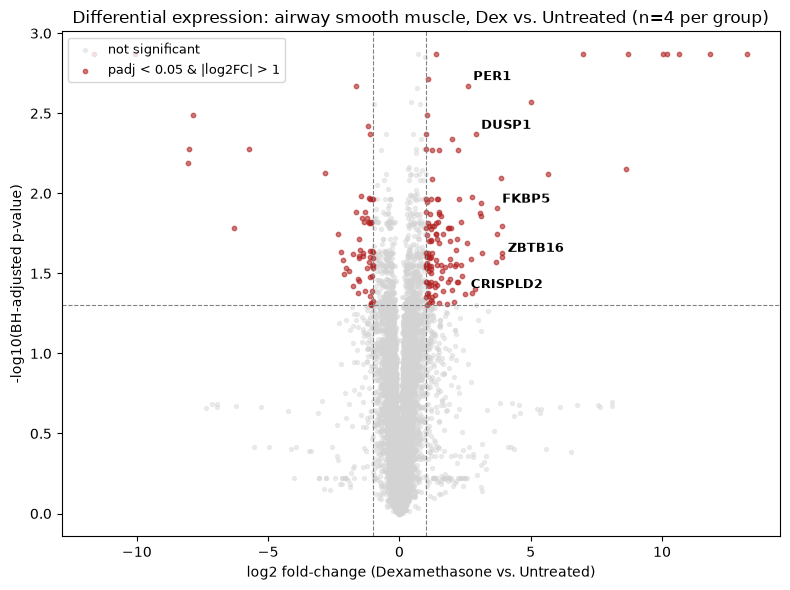

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

neg_log10_padj = -np.log10(results["padj"].replace(0, np.nextafter(0, 1)))
is_sig = (results["padj"] < 0.05) & (results["log2FC"].abs() > 1)

ax.scatter(results.loc[~is_sig, "log2FC"], neg_log10_padj[~is_sig],
           s=8, alpha=0.4, color="lightgray", label="not significant")
ax.scatter(results.loc[is_sig, "log2FC"], neg_log10_padj[is_sig],
           s=10, alpha=0.6, color="firebrick", label="padj < 0.05 & |log2FC| > 1")

for gene in known_genes:
    if gene in results.index and is_sig.get(gene, False):
        row = results.loc[gene]
        ax.annotate(gene, (row["log2FC"], -np.log10(row["padj"])),
                    textcoords="offset points", xytext=(4, 4), fontsize=9, fontweight="bold")

ax.axhline(-np.log10(0.05), color="gray", linestyle="--", linewidth=0.8)
ax.axvline(1, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(-1, color="gray", linestyle="--", linewidth=0.8)
ax.set_xlabel("log2 fold-change (Dexamethasone vs. Untreated)")
ax.set_ylabel("-log10(BH-adjusted p-value)")
ax.set_title("Differential expression: airway smooth muscle, Dex vs. Untreated (n=4 per group)")
ax.legend(loc="upper left", fontsize=9)
fig.tight_layout()
fig.savefig("volcano_plot.png", dpi=150)
plt.show()

## 7. Interpretation

Of the 23,273 genes in the raw matrix, 12,198 passed the expression filter, and 194 of those showed a statistically significant (BH-adjusted p < 0.05), at-least-2-fold change in expression after dexamethasone treatment — 133 up, 61 down. Five of the seven literature-flagged glucocorticoid-response genes I checked (`PER1`, `DUSP1`, `FKBP5`, `ZBTB16`, `CRISPLD2`) landed in that significant set, all strongly up-regulated (log2FC between 2.5 and 3.9), which lines up with dexamethasone's known role as a transcriptional activator acting through the glucocorticoid receptor. `KLF15` and `TSC22D3` showed the same direction of effect but just missed the 0.05 cutoff (padj = 0.054 and 0.062) — in the original paired DESeq2 analysis on raw counts these do reach significance, so I'm reading that near-miss as a real power loss from using an unpaired test on only 4 replicates per group, not evidence the genes aren't actually responding. The fact that most of the known genes clustered near the top of the significance ranking despite the simplifications in this analysis (FPKM instead of raw counts, unpaired instead of paired-by-cell-line) is what makes me trust the pipeline is doing something real rather than just fitting noise.

## 8. AI assistance

See `AI_USAGE.md` in the repo root for the full, specific writeup. Short version: I worked with Claude (Claude Sonnet 5, via Claude Code) to build this notebook end-to-end — picking the dataset and analysis approach, writing the differential-expression/BH-correction code, and debugging a real `uv` environment error hit while setting up the project (OneDrive was interfering with package installation via file hardlinking).